# Лабораторная работа: снижение размерности  

**Методы:** PCA, FastICA, KernelPCA, t-SNE


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

from sklearn.decomposition import PCA, FastICA, KernelPCA
from sklearn.manifold import TSNE

## 1. Загрузка и первичный анализ данных

In [2]:
df = pd.read_csv("cirrhosis.csv")

print("Размер датасета:", df.shape)
display(df.head())

print("\nТипы данных:")
display(df.dtypes)

print("\nКоличество пропусков по столбцам:")
display(df.isna().sum().sort_values(ascending=False))

Размер датасета: (418, 20)


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0



Типы данных:


,0
ID,int64
N_Days,int64
Status,object
Drug,object
Age,int64
Sex,object
Ascites,object
Hepatomegaly,object
Spiders,object
Edema,object



Количество пропусков по столбцам:


,0
Tryglicerides,136
Cholesterol,134
Copper,108
Drug,106
Alk_Phos,106
SGOT,106
Spiders,106
Hepatomegaly,106
Ascites,106
Platelets,11


## 2. Краткая теория

**PCA** — линейный метод снижения размерности, который ищет направления с максимальной дисперсией.  
**FastICA** — метод выделения независимых компонент.  
**KernelPCA** — нелинейное расширение PCA с использованием ядровых функций.  
**t-SNE** — нелинейный метод, хорошо подходящий для визуализации многомерных данных в 2D.

Так как в датасете есть и числовые, и категориальные признаки, а также пропуски, перед применением методов выполняется:
1. заполнение пропусков;
2. кодирование категориальных признаков;
3. масштабирование числовых признаков.


## 3. Подготовка признаков

In [3]:
target_col = "Status"

# Исключаем ID как технический идентификатор
X = df.drop(columns=["ID", target_col])
y = df[target_col].astype(str)

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Количество исходных признаков:", X.shape[1])
print("Числовые признаки:", numeric_features)
print("Категориальные признаки:", categorical_features)

Количество исходных признаков: 18
Числовые признаки: ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']
Категориальные признаки: ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']


## 4. Предобработка данных

In [4]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_prepared = preprocessor.fit_transform(X)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_

print("Размер матрицы после предобработки:", X_prepared.shape)
print("Классы целевой переменной:", list(class_names))

Размер матрицы после предобработки: (418, 25)
Классы целевой переменной: ['C', 'CL', 'D']


## 5. PCA: анализ объяснённой дисперсии

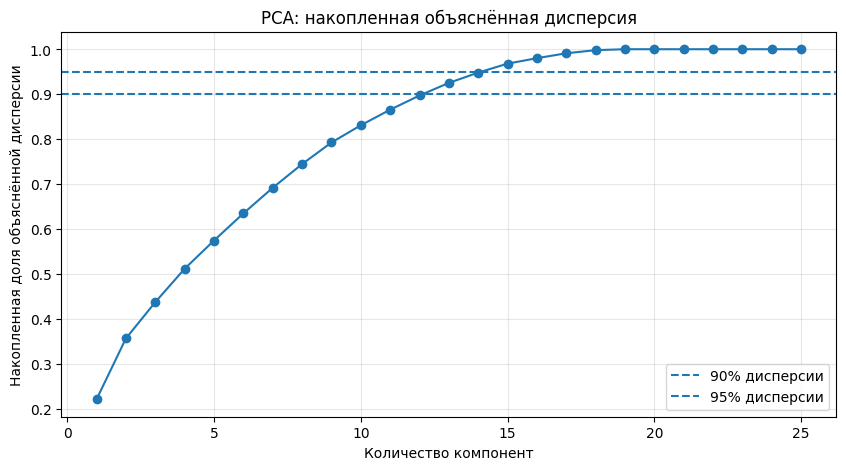

In [5]:
pca_full = PCA()
pca_full.fit(X_prepared)

explained_var = pca_full.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cum_explained_var) + 1), cum_explained_var, marker="o")
plt.axhline(0.90, linestyle="--", label="90% дисперсии")
plt.axhline(0.95, linestyle="--", label="95% дисперсии")
plt.xlabel("Количество компонент")
plt.ylabel("Накопленная доля объяснённой дисперсии")
plt.title("PCA: накопленная объяснённая дисперсия")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 6. Снижение размерности до 2 компонент

In [7]:
methods = {
    "PCA": PCA(n_components=2, random_state=42),
    "FastICA": FastICA(n_components=2, random_state=42, max_iter=2000),
    "KernelPCA (RBF)": KernelPCA(n_components=2, kernel="rbf", gamma=0.05, random_state=42),
    "t-SNE": TSNE(
        n_components=2,
        random_state=42,
        perplexity=30,
        init="pca",
        learning_rate="auto"
    )
}

embeddings = {}

for method_name, model in methods.items():

    embeddings[method_name] = model.fit_transform(X_prepared)


## 7. Визуализация результатов

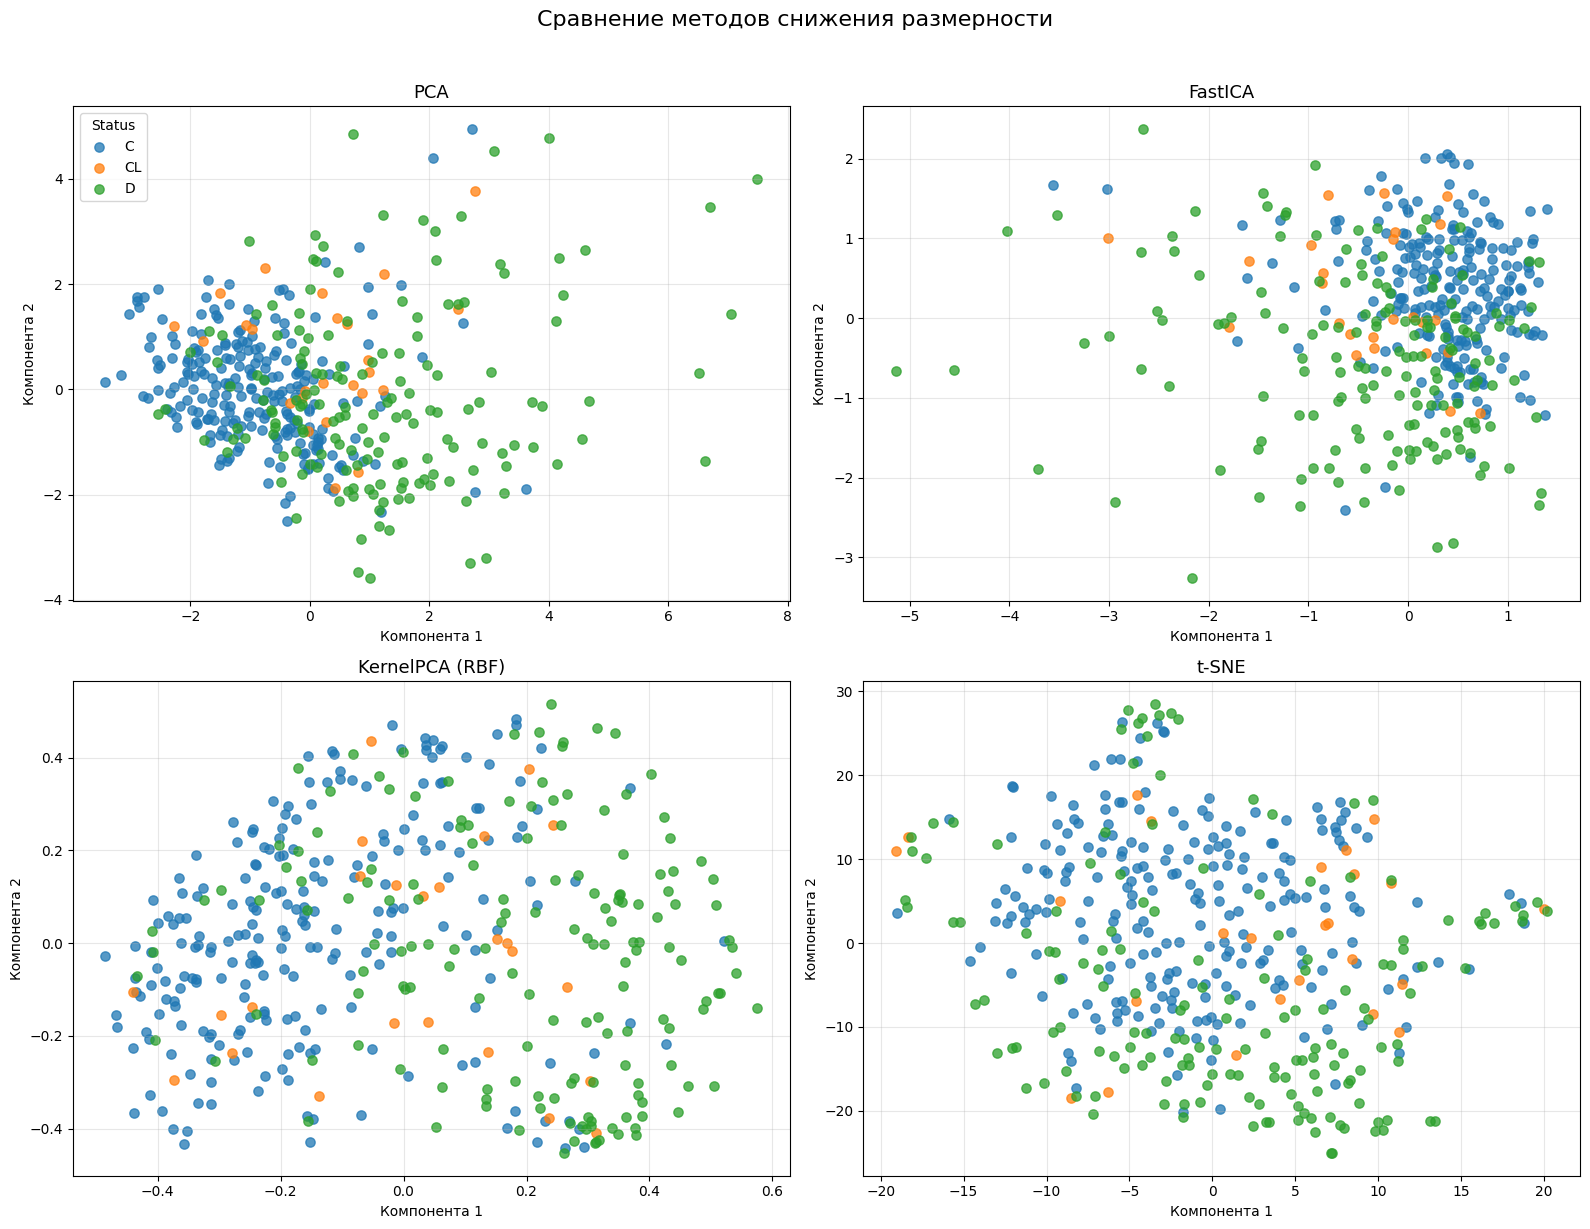

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for ax, (method_name, Z) in zip(axes, embeddings.items()):
    for class_id, class_name in enumerate(class_names):
        mask = (y_encoded == class_id)
        ax.scatter(
            Z[mask, 0],
            Z[mask, 1],
            alpha=0.75,
            s=45,
            label=class_name
        )

    ax.set_title(method_name, fontsize=13)
    ax.set_xlabel("Компонента 1")
    ax.set_ylabel("Компонента 2")
    ax.grid(alpha=0.3)

axes[0].legend(title=target_col)
plt.suptitle("Сравнение методов снижения размерности", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 8. Анализ вкладов признаков для PCA

Топ-15 признаков по вкладу в первые главные компоненты:


,PC1,PC2,max_abs_loading
num__Cholesterol,0.203766,0.438067,0.438067
num__Bilirubin,0.433473,0.159484,0.433473
num__Platelets,-0.120565,0.397980,0.397980
num__Age,0.080162,-0.382123,0.382123
num__Copper,0.361981,0.118005,0.361981
num__N_Days,-0.361914,0.208982,0.361914
num__Albumin,-0.336227,0.222954,0.336227
num__Stage,0.313022,-0.272275,0.313022
num__Tryglicerides,0.244178,0.305553,0.305553
num__Alk_Phos,0.108928,0.305218,0.305218


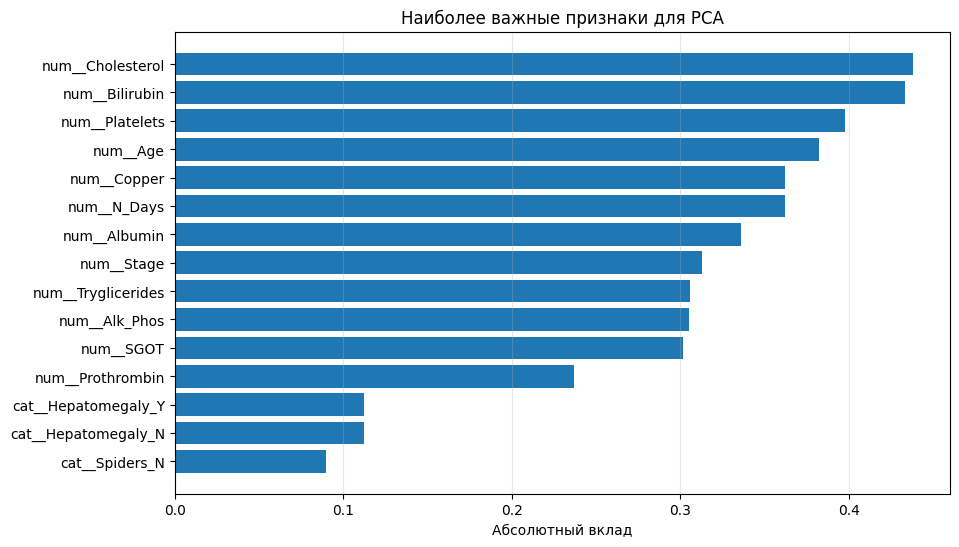

In [9]:
feature_names = preprocessor.get_feature_names_out()

pca_2 = PCA(n_components=2, random_state=42)
X_pca_2 = pca_2.fit_transform(X_prepared)

loadings = pd.DataFrame(
    pca_2.components_.T,
    index=feature_names,
    columns=["PC1", "PC2"]
)

loadings["max_abs_loading"] = loadings[["PC1", "PC2"]].abs().max(axis=1)
top_features = loadings.sort_values("max_abs_loading", ascending=False).head(15)

print("Топ-15 признаков по вкладу в первые главные компоненты:")
display(top_features)

plt.figure(figsize=(10, 6))
plt.barh(top_features.index[::-1], top_features["max_abs_loading"][::-1])
plt.xlabel("Абсолютный вклад")
plt.title("Наиболее важные признаки для PCA")
plt.grid(axis="x", alpha=0.3)
plt.show()

### Краткий текст для отчёта

В работе были изучены методы снижения размерности данных: **PCA, FastICA, KernelPCA и t-SNE**.  
На датасете `cirrhosis.csv` была выполнена предобработка данных: заполнение пропусков, кодирование категориальных признаков и масштабирование числовых признаков. После этого методы были применены для уменьшения размерности до двух компонент. Полученные результаты визуализированы на графиках, что позволило сравнить, как разные методы разделяют объекты по классам `Status`. Дополнительно для метода PCA был проведён анализ объяснённой дисперсии и вкладов признаков.
